# Navier-Stokes 2D + CNN Encoder + Latent SDE

Notebook de estudo SciML para campo fluido 2D incompressivel:
1. Geracao de trajetorias de velocidade (u,v) via passo projetado de Navier-Stokes periodico.
2. Encoder CNN para mapear campo 2D em estado latente z_t.
3. Dinamica Latent SDE no latente.
4. Decoder CNN para reconstruir campo.
5. Loss com reconstrucao, NLL latente, residual de vorticidade, penalidade de divergencia e score bridge.

In [4]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## 1) Navier-Stokes 2D Generator (Periodic, Projection Step)

In [5]:
def ddx_periodic(u, dx):
    return (jnp.roll(u, -1, axis=-1) - jnp.roll(u, 1, axis=-1)) / (2.0 * dx)


def ddy_periodic(u, dy):
    return (jnp.roll(u, -1, axis=-2) - jnp.roll(u, 1, axis=-2)) / (2.0 * dy)


def laplacian_periodic(u, dx, dy):
    u_xx = (jnp.roll(u, -1, axis=-1) - 2.0 * u + jnp.roll(u, 1, axis=-1)) / (dx * dx)
    u_yy = (jnp.roll(u, -1, axis=-2) - 2.0 * u + jnp.roll(u, 1, axis=-2)) / (dy * dy)
    return u_xx + u_yy


def divergence(field, dx, dy):
    u = field[..., 0, :, :]
    v = field[..., 1, :, :]
    return ddx_periodic(u, dx) + ddy_periodic(v, dy)


def vorticity(field, dx, dy):
    u = field[..., 0, :, :]
    v = field[..., 1, :, :]
    return ddx_periodic(v, dx) - ddy_periodic(u, dy)


def project_incompressible(field, dx, dy):
    # field: (2, H, W)
    h, w = field.shape[-2], field.shape[-1]
    u = field[0]
    v = field[1]

    div = ddx_periodic(u, dx) + ddy_periodic(v, dy)

    kx = 2.0 * jnp.pi * jnp.fft.fftfreq(w, d=dx)
    ky = 2.0 * jnp.pi * jnp.fft.fftfreq(h, d=dy)
    KX, KY = jnp.meshgrid(kx, ky, indexing="xy")

    div_hat = jnp.fft.fft2(div)
    k2 = KX**2 + KY**2
    k2_safe = jnp.where(k2 == 0.0, 1.0, k2)

    # Solve: Laplacian(p) = div / dt_effective (dt absorbed in caller scale).
    p_hat = -div_hat / k2_safe
    p_hat = p_hat.at[0, 0].set(0.0 + 0.0j)

    px = jnp.fft.ifft2(1j * KX * p_hat).real
    py = jnp.fft.ifft2(1j * KY * p_hat).real

    u_proj = u - px
    v_proj = v - py
    return jnp.stack([u_proj, v_proj], axis=0)


def random_streamfunction(key, h, w, n_modes=6, amp=0.8):
    x = jnp.linspace(0.0, 2.0 * jnp.pi, w, endpoint=False)
    y = jnp.linspace(0.0, 2.0 * jnp.pi, h, endpoint=False)
    X, Y = jnp.meshgrid(x, y, indexing="xy")

    psi = jnp.zeros((h, w))
    keys = jax.random.split(key, 4 * n_modes)

    for i in range(n_modes):
        kx = i + 1
        ky = i + 1
        a = amp * jax.random.uniform(keys[4 * i + 0], (), minval=-1.0, maxval=1.0) / (i + 1)
        b = amp * jax.random.uniform(keys[4 * i + 1], (), minval=-1.0, maxval=1.0) / (i + 1)
        p1 = 2.0 * jnp.pi * jax.random.uniform(keys[4 * i + 2], ())
        p2 = 2.0 * jnp.pi * jax.random.uniform(keys[4 * i + 3], ())

        psi = psi + a * jnp.sin(kx * X + ky * Y + p1) + b * jnp.cos(ky * X - kx * Y + p2)

    return psi


def initial_velocity_from_psi(key, h, w):
    dx = 2.0 * jnp.pi / w
    dy = 2.0 * jnp.pi / h
    psi = random_streamfunction(key, h, w, n_modes=6, amp=0.6)

    # u = dpsi/dy, v = -dpsi/dx => campo incompressivel por construcao
    u = ddy_periodic(psi, dy)
    v = -ddx_periodic(psi, dx)
    vel = jnp.stack([u, v], axis=0)
    return project_incompressible(vel, dx, dy)


def navier_stokes2d_rollout(key, n_steps=60, h=32, w=32, dt=0.01, nu=0.01):
    dx = 2.0 * jnp.pi / w
    dy = 2.0 * jnp.pi / h

    vel0 = initial_velocity_from_psi(key, h, w)

    def step(vel, _):
        u = vel[0]
        v = vel[1]

        ux = ddx_periodic(u, dx)
        uy = ddy_periodic(u, dy)
        vx = ddx_periodic(v, dx)
        vy = ddy_periodic(v, dy)

        lap_u = laplacian_periodic(u, dx, dy)
        lap_v = laplacian_periodic(v, dx, dy)

        # Adveccao + viscosidade
        adv_u = u * ux + v * uy
        adv_v = u * vx + v * vy

        u_star = u + dt * (-adv_u + nu * lap_u)
        v_star = v + dt * (-adv_v + nu * lap_v)

        vel_star = jnp.stack([u_star, v_star], axis=0)
        vel_next = project_incompressible(vel_star, dx, dy)
        return vel_next, vel_next

    _, traj = jax.lax.scan(step, vel0, xs=None, length=n_steps - 1)
    traj = jnp.concatenate([vel0[None, ...], traj], axis=0)
    return traj


def make_ns_dataset(key, batch=64, n_steps=60, h=32, w=32, dt=0.01, nu=0.01):
    keys = jax.random.split(key, batch)
    X = jax.vmap(lambda k: navier_stokes2d_rollout(k, n_steps=n_steps, h=h, w=w, dt=dt, nu=nu))(keys)
    # X: (B, T, 2, H, W)
    t_grid = jnp.arange(n_steps) * dt
    return X, t_grid

X shape: (64, 60, 2, 32, 32)


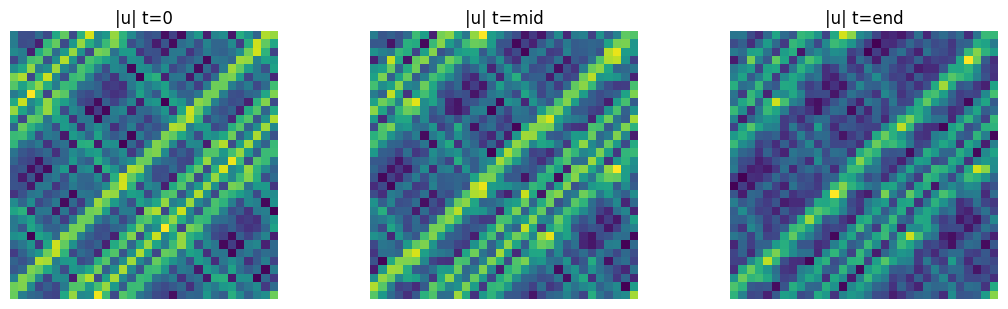

Initial divergence L2: 1.2698048124093475e-07


In [6]:
key = jax.random.PRNGKey(42)
H = W = 32
T = 60
DT = 0.01
NU = 0.01

X, t_grid = make_ns_dataset(key, batch=64, n_steps=T, h=H, w=W, dt=DT, nu=NU)
print("X shape:", X.shape)

speed0 = jnp.sqrt(X[0, 0, 0] ** 2 + X[0, 0, 1] ** 2)
speedm = jnp.sqrt(X[0, T // 2, 0] ** 2 + X[0, T // 2, 1] ** 2)
speede = jnp.sqrt(X[0, -1, 0] ** 2 + X[0, -1, 1] ** 2)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].imshow(speed0, cmap="viridis")
ax[0].set_title("|u| t=0")
ax[1].imshow(speedm, cmap="viridis")
ax[1].set_title("|u| t=mid")
ax[2].imshow(speede, cmap="viridis")
ax[2].set_title("|u| t=end")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

dx = 2.0 * jnp.pi / W
dy = 2.0 * jnp.pi / H
div0 = divergence(X[0, 0][None, ...], dx, dy)
print("Initial divergence L2:", float(jnp.sqrt(jnp.mean(div0**2))))

## 2) CNN Encoder/Decoder + Latent SDE

In [7]:
class NSLatentSDE(eqx.Module):
    enc1: eqx.nn.Conv2d
    enc2: eqx.nn.Conv2d
    enc3: eqx.nn.Conv2d
    enc_fc: eqx.nn.Linear

    dec_fc: eqx.nn.Linear
    dec1: eqx.nn.Conv2d
    dec2: eqx.nn.Conv2d
    dec_out: eqx.nn.Conv2d

    drift: eqx.nn.MLP
    diffusion: eqx.nn.MLP
    score: eqx.nn.MLP

    latent_dim: int
    h: int
    w: int

    def __init__(self, key, h=32, w=32, latent_dim=48, width=128, depth=2):
        k = jax.random.split(key, 11)

        self.enc1 = eqx.nn.Conv2d(2, 24, kernel_size=3, stride=2, padding=1, key=k[0])
        self.enc2 = eqx.nn.Conv2d(24, 48, kernel_size=3, stride=2, padding=1, key=k[1])
        self.enc3 = eqx.nn.Conv2d(48, 48, kernel_size=3, stride=1, padding=1, key=k[2])
        self.enc_fc = eqx.nn.Linear(48 * (h // 4) * (w // 4), latent_dim, key=k[3])

        self.dec_fc = eqx.nn.Linear(latent_dim, 48 * (h // 4) * (w // 4), key=k[4])
        self.dec1 = eqx.nn.Conv2d(48, 48, kernel_size=3, stride=1, padding=1, key=k[5])
        self.dec2 = eqx.nn.Conv2d(48, 24, kernel_size=3, stride=1, padding=1, key=k[6])
        self.dec_out = eqx.nn.Conv2d(24, 2, kernel_size=3, stride=1, padding=1, key=k[7])

        self.drift = eqx.nn.MLP(latent_dim + 1, latent_dim, width_size=width, depth=depth, key=k[8])
        self.diffusion = eqx.nn.MLP(latent_dim + 1, latent_dim, width_size=width, depth=depth, key=k[9])
        self.score = eqx.nn.MLP(latent_dim + 1, latent_dim, width_size=width, depth=depth, key=k[10])

        self.latent_dim = latent_dim
        self.h = h
        self.w = w

    def encode_frame(self, uv):
        x = jax.nn.swish(self.enc1(uv))
        x = jax.nn.swish(self.enc2(x))
        x = jax.nn.swish(self.enc3(x))
        return self.enc_fc(x.reshape(-1))

    def decode_frame(self, z):
        x = self.dec_fc(z).reshape(48, self.h // 4, self.w // 4)

        x = jax.image.resize(x, (48, self.h // 2, self.w // 2), method="linear")
        x = jax.nn.swish(self.dec1(x))

        x = jax.image.resize(x, (48, self.h, self.w), method="linear")
        x = jax.nn.swish(self.dec2(x))
        uv = self.dec_out(x)
        return uv

    def drift_fn(self, z, t):
        inp = jnp.concatenate([z, t], axis=-1)
        return jax.vmap(self.drift)(inp)

    def diffusion_fn(self, z, t):
        inp = jnp.concatenate([z, t], axis=-1)
        raw = jax.vmap(self.diffusion)(inp)
        return jax.nn.softplus(raw) + 1e-3

    def score_fn(self, z, t):
        inp = jnp.concatenate([z, t], axis=-1)
        return jax.vmap(self.score)(inp)


def encode_sequence(model, x):
    # x: (B,T,2,H,W) -> (B,T,D)
    return jax.vmap(lambda xb: jax.vmap(model.encode_frame)(xb))(x)


def decode_sequence(model, z):
    # z: (B,T,D) -> (B,T,2,H,W)
    return jax.vmap(lambda zb: jax.vmap(model.decode_frame)(zb))(z)

## 3) Losses: Reconstruction + Latent NLL + Vorticity Residual + Divergence + Score Bridge

In [8]:
def mse(a, b):
    return jnp.mean((a - b) ** 2)


def huber(a, b, delta=5.0):
    r = a - b
    ar = jnp.abs(r)
    q = jnp.minimum(ar, delta)
    l = ar - q
    return jnp.mean(0.5 * q**2 + delta * l)


def vorticity_residual(uv_t, uv_next, dt, nu, dx, dy):
    # uv_t/uv_next: (N,2,H,W)
    om_t = vorticity(uv_t, dx, dy)
    om_next = vorticity(uv_next, dx, dy)

    dom_dt = (om_next - om_t) / dt

    u = uv_t[:, 0]
    v = uv_t[:, 1]
    om_x = ddx_periodic(om_t, dx)
    om_y = ddy_periodic(om_t, dy)
    om_lap = laplacian_periodic(om_t, dx, dy)

    res = dom_dt + u * om_x + v * om_y - nu * om_lap
    return res


def loss_terms(model, x_batch, t_grid, dt, nu, key):
    bsz, tlen, _, h, w = x_batch.shape
    dx = 2.0 * jnp.pi / w
    dy = 2.0 * jnp.pi / h

    z = encode_sequence(model, x_batch)
    x_hat = decode_sequence(model, z)

    recon = mse(x_hat, x_batch)

    z_t = z[:, :-1, :]
    z_next = z[:, 1:, :]
    dz = z_next - z_t

    t_bt = jnp.broadcast_to(t_grid[:-1][None, :, None], (bsz, tlen - 1, 1))

    zf = z_t.reshape(-1, model.latent_dim)
    dzf = dz.reshape(-1, model.latent_dim)
    tf = t_bt.reshape(-1, 1)

    drift = model.drift_fn(zf, tf)
    diffusion = model.diffusion_fn(zf, tf)

    mean = drift * dt
    var = jnp.clip((diffusion ** 2) * dt, 1e-6, 100.0)
    nll_latent = 0.5 * jnp.mean(((dzf - mean) ** 2) / var + jnp.log(var))

    # Vorticity PDE residual no campo reconstruido
    xh_t = x_hat[:, :-1, :, :, :].reshape(-1, 2, h, w)
    xh_next = x_hat[:, 1:, :, :, :].reshape(-1, 2, h, w)
    rv = vorticity_residual(xh_t, xh_next, dt, nu, dx, dy)
    pde_vorticity = jnp.mean(rv ** 2)

    # Divergence-free penalty
    div_val = divergence(x_hat.reshape(-1, 2, h, w), dx, dy)
    divergence_penalty = jnp.mean(div_val ** 2)

    # Score matching no latente
    key_noise, _ = jax.random.split(key)
    sigma = 0.05
    eps = jax.random.normal(key_noise, zf.shape)
    z_noisy = zf + sigma * eps

    score_noisy = model.score_fn(z_noisy, tf)
    score_target = -(z_noisy - zf) / (sigma ** 2)
    score_dsm = mse(score_noisy, score_target)

    # Score bridge no latente
    bridge_target = jax.lax.stop_gradient((dzf - mean) / jnp.clip(var, 1e-4, 100.0))
    bridge_target = jnp.clip(bridge_target, -50.0, 50.0)
    score_now = model.score_fn(zf, tf)
    score_bridge = huber(score_now, bridge_target, delta=5.0)

    # Calibracao de difusao
    sigma_emp = jnp.std(dzf) / jnp.sqrt(dt)
    sigma_emp = jnp.clip(sigma_emp, 5e-2, 2.0)
    diffusion_calib = mse(jnp.log(diffusion + 1e-8), jnp.log(jnp.full_like(diffusion, sigma_emp)))

    return {
        "recon": recon,
        "nll_latent": nll_latent,
        "pde_vorticity": pde_vorticity,
        "divergence_penalty": divergence_penalty,
        "score_dsm": score_dsm,
        "score_bridge": score_bridge,
        "diffusion_calib": diffusion_calib,
    }


def total_loss(model, x_batch, t_grid, dt, nu, key, w):
    terms = loss_terms(model, x_batch, t_grid, dt, nu, key)
    total = (
        w["recon"] * terms["recon"]
        + w["nll_latent"] * terms["nll_latent"]
        + w["pde_vorticity"] * terms["pde_vorticity"]
        + w["divergence_penalty"] * terms["divergence_penalty"]
        + w["score_dsm"] * terms["score_dsm"]
        + w["score_bridge"] * terms["score_bridge"]
        + w["diffusion_calib"] * terms["diffusion_calib"]
    )
    return total, terms


@eqx.filter_jit
def train_step(model, opt_state, x_batch, t_grid, dt, nu, key, optimizer, w):
    (loss, terms), grads = eqx.filter_value_and_grad(total_loss, has_aux=True)(
        model, x_batch, t_grid, dt, nu, key, w
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, terms

In [ ]:
# Treino
key = jax.random.PRNGKey(2026)
model = NSLatentSDE(key, h=H, w=W, latent_dim=48, width=128, depth=2)
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

weights = {
    "recon": 1.0,
    "nll_latent": 1.0,
    "pde_vorticity": 0.5,
    "divergence_penalty": 1.0,
    "score_dsm": 0.01,
    "score_bridge": 0.01,
    "diffusion_calib": 3.0,
}

num_steps = 250
batch_size = 12

history = {
    k: []
    for k in [
        "total",
        "recon",
        "nll_latent",
        "pde_vorticity",
        "divergence_penalty",
        "score_dsm",
        "score_bridge",
        "diffusion_calib",
    ]
}

for step in range(1, num_steps + 1):
    key, key_idx, key_tr = jax.random.split(key, 3)
    idx = jax.random.choice(key_idx, X.shape[0], shape=(batch_size,), replace=False)
    xb = X[idx]

    model, opt_state, loss, terms = train_step(
        model, opt_state, xb, t_grid, DT, NU, key_tr, optimizer, weights
    )

    history["total"].append(float(loss))
    for k in terms:
        history[k].append(float(terms[k]))

    if step % 50 == 0:
        print(
            f"step {step:03d} | total={loss:.4f} | recon={terms['recon']:.4f} | "
            f"nll={terms['nll_latent']:.4f} | vort={terms['pde_vorticity']:.4f} | div={terms['divergence_penalty']:.4f}"
        )

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["total"], label="total")
ax[0].plot(history["recon"], label="recon")
ax[0].plot(history["nll_latent"], label="nll_latent")
ax[0].plot(history["pde_vorticity"], label="pde_vorticity")
ax[0].plot(history["divergence_penalty"], label="div_pen")
ax[0].set_title("Main losses")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["score_dsm"], label="score_dsm")
ax[1].plot(history["score_bridge"], label="score_bridge")
ax[1].plot(history["diffusion_calib"], label="diffusion_calib")
ax[1].set_title("Score + diffusion")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4) Rollout from Latent SDE and compare speed maps

In [ ]:
def rollout_latent_ns(model, key, x0, t_grid, dt):
    # x0: (B,2,H,W)
    z0 = jax.vmap(model.encode_frame)(x0)

    def step(z, inp):
        key_step, t_scalar = inp
        t = jnp.full((z.shape[0], 1), t_scalar)

        drift = model.drift_fn(z, t)
        diffusion = model.diffusion_fn(z, t)
        dW = jax.random.normal(key_step, z.shape) * jnp.sqrt(dt)

        z_next = z + drift * dt + diffusion * dW
        x_next = jax.vmap(model.decode_frame)(z_next)
        return z_next, x_next

    keys = jax.random.split(key, t_grid.shape[0])
    _, xtraj = jax.lax.scan(step, z0, (keys, t_grid))
    return jnp.swapaxes(xtraj, 0, 1)


key_sim = jax.random.PRNGKey(111)
x0 = X[:6, 0]
X_sim = rollout_latent_ns(model, key_sim, x0, t_grid, DT)
print("X_sim shape:", X_sim.shape)

In [ ]:
sample = 0
times = [0, T // 2, T - 1]

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
for j, tt in enumerate(times):
    sp_real = jnp.sqrt(X[sample, tt, 0] ** 2 + X[sample, tt, 1] ** 2)
    sp_sim = jnp.sqrt(X_sim[sample, tt, 0] ** 2 + X_sim[sample, tt, 1] ** 2)

    ax[0, j].imshow(sp_real, cmap="magma")
    ax[0, j].set_title(f"Real |u| t={tt}")
    ax[0, j].axis("off")

    ax[1, j].imshow(sp_sim, cmap="magma")
    ax[1, j].set_title(f"Sim |u| t={tt}")
    ax[1, j].axis("off")

plt.tight_layout()
plt.show()

dx = 2.0 * jnp.pi / W
dy = 2.0 * jnp.pi / H
div_real = divergence(X[sample, -1][None, ...], dx, dy)
div_sim = divergence(X_sim[sample, -1][None, ...], dx, dy)
print("Real final div L2:", float(jnp.sqrt(jnp.mean(div_real**2))))
print("Sim final div L2:", float(jnp.sqrt(jnp.mean(div_sim**2))))

## Next upgrades

1. Trocar encoder/decoder CNN por FNO 2D para operar melhor em multiplas resolucoes.
2. Usar rollout teacher-forcing parcial para reduzir drift de longo prazo.
3. Adicionar forcante externa e regime turbulento com Re maior.